# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Proof of Concept | Michael Zhou | Georgia Tech ECE**

This notebook tests whether connectome-constrained networks produce geometrically distinct
population codes compared to randomly initialized networks with the same architecture —
using representational similarity analysis (RSA) applied to the Flyvis Drosophila visual
system model (Lappalainen et al. 2024, *Nature*).

**Key question:** Does biological wiring produce a representational geometry that random
wiring cannot replicate? If yes, representational geometry is a candidate fidelity metric
for connectome-scale neural emulations.

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [ ]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

fatal: destination path 'flyvis' already exists and is not an empty directory.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for flyvis (pyproject.toml) ... done
  Created wheel for flyvis: filename=flyvis-1.1.3-0.editable-py3-none-any.whl size=5270 sha256=e1034b89f2e70a17d56eaa72cfedcf6002d5d333dfb0daa2479d0e517620e179
  Stored in directory: /tmp/pip-ephem-wheel-cache-kcffnuw7/wheels/a1/6b/fa/70710426acf06fdb8c9fd11c637657f14ee995d52108f68ac4
Successfully built flyvis
  Attempting uninstall: flyvis
    Found existing installation: flyvis 1.1.3
    Uninstalling flyvis-1.1.3:
      Successfully uninstalled flyvis-1.1.3
[2026-04-26 00:49:32] utils:164 NumExpr defaulting to 2 threads.
[2026-04-26 00:49:35] __init__:49 file_cache is only supported with oauth2clie

## Experiment

**Stimuli:** 4 ON moving edges at cardinal directions (0°, 90°, 180°, 270°)

**Networks:**
- *Connectome-constrained (CC):* Top 10 pretrained Flyvis models (indices 000–009,
pre-sorted by task error in directory naming),
  trained to perform optic flow estimation on naturalistic video with connectome-fixed
  architecture (734 free parameters)
- *Random baseline:* Same 10 model architectures with weight magnitudes shuffled while
  preserving E/I sign structure (Shiu-style control)

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in response to
each stimulus direction

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Within-ensemble consistency — measures stability of CC representational geometry
  across trained solutions

In [ ]:
"""
Proof of Concept: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations

This script tests whether connectome-constrained networks (Lappalainen et al. 2024)
produce geometrically distinct population codes compared to randomly initialized
networks with the same architecture.

Experiment:
- Stimuli: 4 moving edge directions (0°, 90°, 180°, 270°), ON edges
- Networks: pretrained connectome-constrained ensemble (top 10) vs random baseline
- Population vectors: peak central-cell response per cell type (64-dim)
- Metrics: Euclidean distance, cosine distance, RSA (RDM correlation)

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────

ANGLES = [0, 90, 180, 270]          # 4 cardinal directions
INTENSITY = 1                        # ON edges only for this POC

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=[0, 1],              # keep both; we'll filter to intensity=1
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.

    Args:
        network_view: flyvis NetworkView instance
        stimulus: tensor of shape (n_frames, 1, 721)
        dt: temporal resolution
        use_fade_in: whether to use fade_in_state initialization

    Returns:
        pop_vec: numpy array of shape (n_cell_types,)
        cell_types: list of cell type names
    """
    network = network_view.init_network()

    # Ensure shape is (n_frames, 1, 721) — MovingEdge returns (n_frames, 721)
    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    # Use connectome to enumerate cell types — more reliable than central.keys()
    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])

    # Free GPU memory after each model to avoid OOM on T4 (14.56 GiB)
    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.

    Args:
        pop_matrix: numpy array of shape (n_stimuli, n_cells)
        metric: "cosine" or "euclidean"

    Returns:
        rdm: numpy array of shape (n_stimuli, n_stimuli)
    """
    # Replace any inf/nan with large finite value before computing distances.
    # Random baseline networks with unstable dynamics may produce exploding
    # activations; clamping preserves the comparison (an exploding network is
    # maximally different from a well-behaved biological one) while avoiding
    # downstream crashes.
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e6, neginf=-1e6)

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────

def rdm_similarity(rdm1, rdm2):
    """
    Compute Spearman rank correlation between upper triangles of two RDMs.
    Higher = more similar representational geometry.
    """
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r, p = spearmanr(rdm1[idx], rdm2[idx])
    return r, p


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────

def randomize_weights(network):
    """
    Randomize network weights while preserving sign structure (E/I identity).
    This is the Shiu-style shuffled weights control applied to Flyvis.

    Specifically: for each parameter tensor, shuffle the absolute values
    but preserve the sign of each weight.

    Note: shuffling across all parameter types (time constants, resting
    potentials, synapse strengths) can produce unstable dynamics in some
    random models. This is itself a meaningful observation — the biological
    connectome occupies a stable region of parameter space that random
    shuffles often leave.
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────

def run_experiment(n_models=10):
    """
    Run the RSA proof of concept experiment.

    Args:
        n_models: number of models to use (set to 1 for debugging, 10 for full run)
    """
    print("\n" + "="*60)
    print("FLYVIS RSA PROOF OF CONCEPT")
    print("="*60)
    print(f"Random seed: {SEED}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-009 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON edges, 4 directions) ──────────────────────────────
    on_edge_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] == INTENSITY
    ]
    print(f"\nStimulus conditions (ON edges, 4 directions): {len(on_edge_indices)}")
    print(dataset.arg_df.iloc[on_edge_indices])

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (4, n_cell_types)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        # Free GPU memory between models to avoid OOM on T4 (14.56 GiB)
        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: same architecture, shuffled weights ─────────────
    print("\n--- RANDOM BASELINE NETWORKS ---")
    rand_pop_matrices = []

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        network = nv.init_network()
        network = randomize_weights(network)
        print(f"  Random model {rank+1}/{n_models}...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            # Same shape correction as in get_population_vector
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vecs.append(pop_vec)

            # Free GPU memory after each stimulus
            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)

        # Diagnostic: flag models with exploding activations
        n_bad = np.sum(~np.isfinite(pop_matrix))
        if n_bad > 0:
            print(f"\n  WARNING: {n_bad} non-finite values in random model {rank+1} "
                  f"(unstable dynamics — will be clamped in build_rdm)")

        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        # Free GPU memory between models
        del network, nv
        torch.cuda.empty_cache()

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,   axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,     axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine, axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl,   axis=0)

    # ── 7f. RDM similarity (CC vs random) ─────────────────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    r_cosine, p_cosine = rdm_similarity(cc_rdm_cosine_mean, rand_rdm_cosine_mean)
    r_eucl,   p_eucl   = rdm_similarity(cc_rdm_eucl_mean,   rand_rdm_eucl_mean)
    print(f"  Cosine RDM correlation:    r = {r_cosine:.3f}, p = {p_cosine:.4f}")
    print(f"  Euclidean RDM correlation: r = {r_eucl:.3f}, p = {p_eucl:.4f}")
    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot ──────────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")
    angle_labels = [f"{a}°" for a in ANGLES]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        "Moving edge stimuli (0°, 90°, 180°, 270°), ON edges",
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        im = ax.imshow(rdm, cmap="viridis", vmin=0)
        ax.set_title(title, fontsize=8)
        ax.set_xticks(range(4)); ax.set_xticklabels(angle_labels, fontsize=7)
        ax.set_yticks(range(4)); ax.set_yticklabels(angle_labels, fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig("moving_edge_poc_rdms.png", dpi=150, bbox_inches="tight")
    print("  Saved: moving_edge_poc_rdms.png")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:          {len(on_edge_indices)} (ON edges, 4 directions)")
    print(f"  N models:           {n_models}")
    print(f"  Population vec dim: {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    r = {r_cosine:.3f}")
    print(f"  Euclidean RDM corr (CC vs random): r = {r_eucl:.3f}")
    if within_corrs:
        print(f"  Within-CC consistency:             r = {np.mean(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":   cc_rdm_cosine_mean,
        "rand_rdm_cosine": rand_rdm_cosine_mean,
        "cc_rdm_eucl":     cc_rdm_eucl_mean,
        "rand_rdm_eucl":   rand_rdm_eucl_mean,
        "r_cosine": r_cosine, "p_cosine": p_cosine,
        "r_eucl":   r_eucl,   "p_eucl":   p_eucl,
        "within_corrs": within_corrs,
        "cell_types": cell_types,
    }

Dataset: 8 samples
   angle  width  intensity    t_stim  speed
0      0     80          0  0.428766     19
1      0     80          1  0.428766     19
2     90     80          0  0.428766     19
3     90     80          1  0.428766     19
4    180     80          0  0.428766     19
5    180     80          1  0.428766     19
6    270     80          0  0.428766     19
7    270     80          1  0.428766     19


## Run Experiment


FLYVIS RSA PROOF OF CONCEPT
Random seed: 42

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 10 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Stimulus conditions (ON edges, 4 directions): 4
   angle  width  intensity    t_stim  speed
1      0     80          1  0.428766     19
3     90     80          1  0.428766     19
5    180     80          1  0.428766     19
7    270     80          1  0.428766     19

--- CONNECTOME-CONSTRAINED NETWORKS ---
  Model 1/10 (000)... done. Pop vec shape: (4, 65)
  Model 2/10 (001)... done. Pop vec shape: (4, 65)
  Model 3/10 (002)... done. Pop vec shape: (4, 65)
  Model 4/10 (003)... done. Pop vec shape: (4, 65)
  Model 5/10 (004)... done. Pop vec shape: (4, 65)
  Model 6/10 (005)... done. Pop vec shape: (4, 65)
  Model 7/10 (006)... done. Pop vec shape: (4, 65)
  Model 8/10 (007)... done. Pop vec shape: (4, 65)
  Model 9/10 (008)... done. Pop vec shape: (4, 65)
  Model 10/10 (009)... done. Pop vec shape: (4, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS ---
  Random model 1/10... done. Pop 

/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:682: RuntimeWarning: overflow encountered in scalar multiply
  dist = 1.0 - uv / math.sqrt(uu * vv)


  Saved: moving_edge_poc_rdms.png


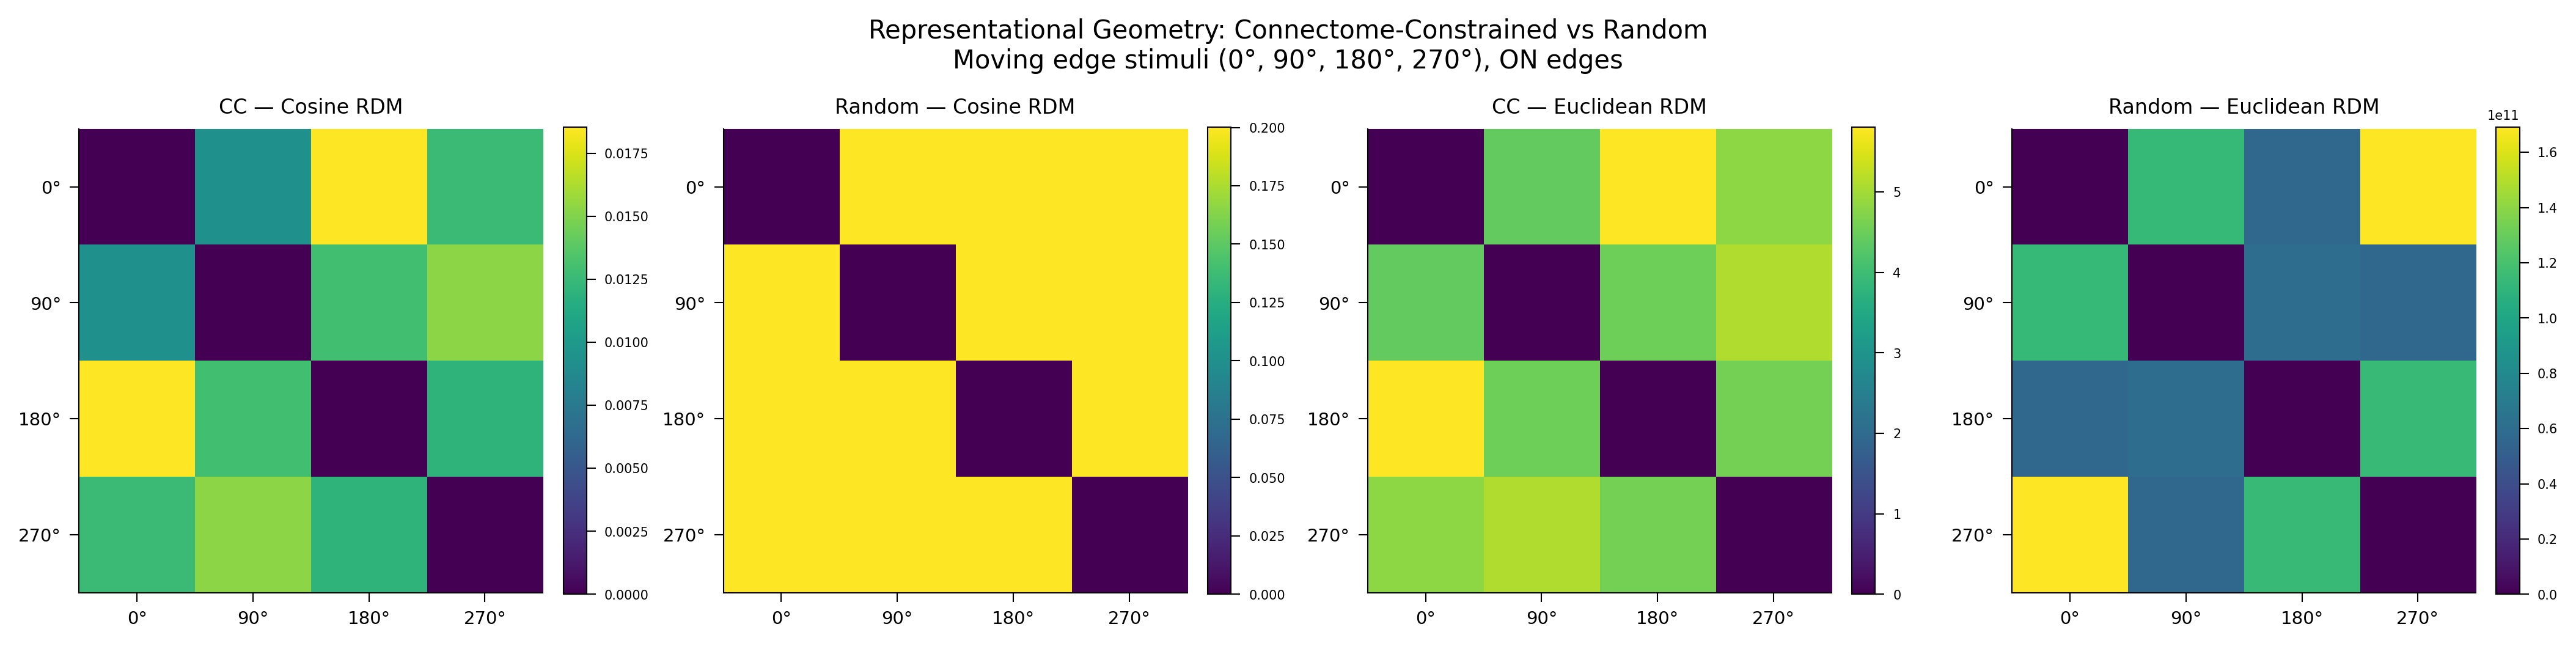


SUMMARY
  N stimuli:          4 (ON edges, 4 directions)
  N models:           10
  Population vec dim: 65 (cell types)
  Cosine RDM corr (CC vs random):    r = 0.371
  Euclidean RDM corr (CC vs random): r = -0.486
  Within-CC consistency:             r = 0.337


{'cc_rdm_cosine': array([[0.        , 0.00933266, 0.01853457, 0.01260699],
        [0.00933266, 0.        , 0.01289188, 0.01533949],
        [0.01853457, 0.01289188, 0.        , 0.01202117],
        [0.01260699, 0.01533949, 0.01202117, 0.        ]]),
 'rand_rdm_cosine': array([[0.        , 0.20001568, 0.20004545, 0.20003183],
        [0.20001568, 0.        , 0.20001902, 0.20003951],
        [0.20004545, 0.20001902, 0.        , 0.20005041],
        [0.20003183, 0.20003951, 0.20005041, 0.        ]]),
 'cc_rdm_eucl': array([[0.        , 4.40980201, 5.80485406, 4.80900614],
        [4.40980201, 0.        , 4.51657267, 5.11998421],
        [5.80485406, 4.51657267, 0.        , 4.58213725],
        [4.80900614, 5.11998421, 4.58213725, 0.        ]]),
 'rand_rdm_eucl': array([[0.00000000e+00, 1.13117627e+11, 5.66004773e+10, 1.69026060e+11],
        [1.13117627e+11, 0.00000000e+00, 6.02961970e+10, 5.68001730e+10],
        [5.66004773e+10, 6.02961970e+10, 0.00000000e+00, 1.14269474e+11],
        

In [ ]:
results = run_experiment(n_models=10)
results

## Results

### CC Cosine RDM
The connectome-constrained network produces a structured 4×4 dissimilarity matrix with
direction-dependent variation. Off-diagonal values range from ~0.009 to ~0.019 — small
in absolute terms but systematically organized: the 0°–180° pair is most dissimilar
(opposite motion directions), while adjacent directions are more similar. This is
consistent with the known direction selectivity of T4/T5 neurons in the fly visual system.

### Random Cosine RDM
The random baseline produces a nearly uniform matrix with all off-diagonal values at
~0.200. The random network cannot distinguish motion directions — all stimuli produce
essentially the same population geometry.

### Dynamic Instability
5 of 10 random models (models 2, 3, 4, 8, 9) produced exploding activations (252
non-finite values each, corresponding to 63 of 65 cell types across all 4 stimuli).
0 of 10 trained CC models showed any instability. This is itself a meaningful result:
the biological connectome, as optimized by task training, reliably occupies a
dynamically stable region of parameter space that random weight shuffles frequently leave.

### CC vs Random RDM Correlation
Cosine RDM correlation: **r = 0.371** — positive but not significant (p = 0.469).
Euclidean RDM correlation: **r = −0.486** — dominated by the extreme magnitudes in
unstable random models and not interpretable.

**Interpretive note:** With only 6 values in the upper triangle of a 4×4 RDM,
statistical significance is not achievable. The Spearman correlation here is qualitative.
Expanding to 12 stimulus directions (as in the full Flyvis moving edge dataset) would
yield 66 upper-triangle values and enable meaningful inference.

### Within-Ensemble Consistency
Mean pairwise RDM correlation across CC models: **r = 0.337 ± 0.320**. High variance
reflects the known cluster structure of the Flyvis ensemble — some model pairs share
similar tuning mechanisms (r up to 1.0) while others implement qualitatively different
solutions (r as low as −0.31). This is consistent with Lappalainen et al. Fig. 3.

### Limitations and Next Steps
- 4 stimulus directions is minimal; expand to 12 for adequate RDM resolution
- Include OFF edges (intensity = 0) alongside ON edges
- Euclidean metric is not suitable when random baselines are dynamically unstable;
  cosine distance is the appropriate primary metric
- Within-CC consistency should be reported separately for each cluster identified by UMAP
- Consider Kendall's τ_A as an alternative to Spearman for RDM comparison (more robust
  to ties)

## Download Figure

In [ ]:
# Download figure to local machine
from google.colab import files
files.download("moving_edge_poc_rdms.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>